## Compare EDELWEISS to VIIRS

In [1]:
from edelassim.observations import EdelweissGrandesRoussesGrid

data_folder = "/home/imperatoren/work/edelweiss_assimilation/observation_operator/data/grandesrousses"
simulation_folder = "/home/imperatoren/work/edelweiss_assimilation/simulations/postprocess/grandesrousses250m"
period = slice("2021-11-01", "2022-07-01")
grandesrousses_grid = EdelweissGrandesRoussesGrid()

In [2]:
import xarray as xr
from edelassim.bdclim import crop_bdclim, find_station_locations
from edelassim.observations import scale_virrs

forest_mask_path = f"{data_folder}/forest_mask/corine_grandesrousses_max.nc"
forest_mask = xr.open_dataarray(forest_mask_path, engine="rasterio").sel(band=1).drop_vars("band")

no_assim_all_path = f"{simulation_folder}/no_assim/all_members/PRO.nc"
edel = xr.open_dataset(no_assim_all_path).where(forest_mask == 0).sel(time=period).data_vars["DSN_T_ISBA"]

viirs_filepath = f"{data_folder}/reprojected_from_france_viirs/mf_fsc_l3_grandesrousses_wy_2021_2022.nc"
viirs = scale_virrs(xr.open_dataset(viirs_filepath).where(forest_mask == 0).sel(time=period).data_vars["snow_cover_fraction"])

pleiades_path = f"{data_folder}/pleiades_time_series/pleaides_granderousses_all.nc"
pleiades = xr.open_dataset(pleiades_path).where(forest_mask == 0).sel(time=period).data_vars["snow_depth"]

bdclim_path = "/home/imperatoren/work/edelweiss_assimilation/data/snow_depth/bdclim/snow_depth_bdclim.nc"
bdclim = crop_bdclim(bdclim_path, grid=grandesrousses_grid).data_vars["neigetotx"].sel(time=period) / 100
x_poste, y_poste = find_station_locations(bdclim_dataset=bdclim)

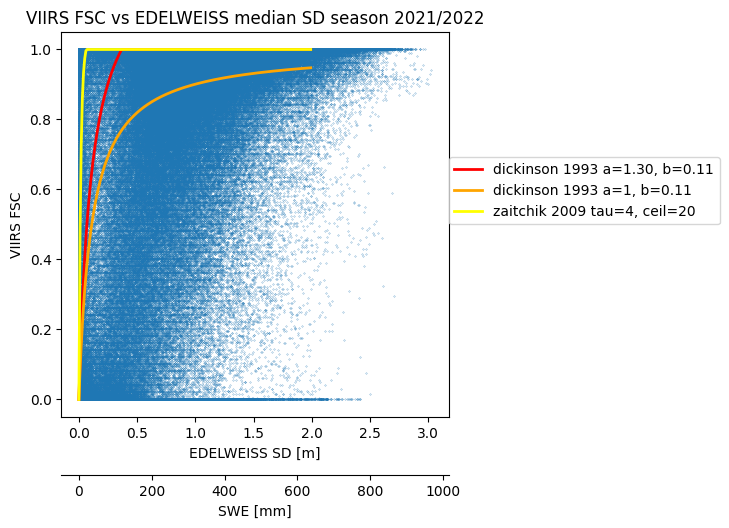

In [ ]:
from matplotlib import pyplot as plt
import numpy as np
from edelassim.observation_operators import dickinson, zaitchik

fig, ax = plt.subplots(figsize=(5, 5))
sd = edel.sel(x=viirs["x"], y=viirs["y"], method="nearest", time=viirs.coords["time"]).median(dim="member")
am, bm = 1.3, 0.11
tau, ceil = 4, 20
mean_snow_density = 320  # kg/m3
sd_axis = np.arange(0, 2, 0.01)  # m


def sd_to_swe(x):
    # SD meters, SWE mm
    mean_snow_density = 320  # kg/m^3
    water_density = 1000  # kg/m^3
    m_to_mm_scale = 1000
    return x * mean_snow_density / water_density * m_to_mm_scale


def swe_to_sd(x):
    # SD meters, SWE mm
    mean_snow_density = 320  # kg/m^3
    water_density = 1000  # kg/m^3
    m_to_mm_scale = 1000
    return x / mean_snow_density * water_density / m_to_mm_scale


swe_axis = sd_to_swe(sd_axis)


ax.scatter(sd, viirs, s=0.04)
ax.plot(
    sd_axis,
    dickinson(sd=sd_axis, a=am, b=bm),
    "r",
    linewidth=2,
    label=f"dickinson 1993 a={am:.2f}, b={bm:.2f}",
)
ax.plot(
    sd_axis,
    dickinson(sd=sd_axis, a=1, b=0.11),
    "orange",
    linewidth=2,
    label="dickinson 1993 a=1, b=0.11",
)
ax.plot(
    sd_axis,
    zaitchik(swe=swe_axis, tau_scf=tau, swe_full_snow_cover=ceil),
    "yellow",
    linewidth=2,
    label=f"zaitchik 2009 tau={tau}, ceil={ceil}",
)
# ax.plot(np.arange(0, 2, 0.01), dickinson(sd=np.arange(0, 2, 0.01), a=am, b=bm), "r", linewidth=2)
ax.set_title("VIIRS FSC vs EDELWEISS median SD season 2021/2022")
ax.set_ylabel("VIIRS FSC")
ax.set_xlabel("EDELWEISS SD [m]")
secax = ax.secondary_xaxis(-0.15, functions=(sd_to_swe, swe_to_sd))
secax.set_xlabel("SWE [mm]")
ax.legend(loc=(1, 0.5))

Text(0.5, 0, 'EDELWEISS FSC')

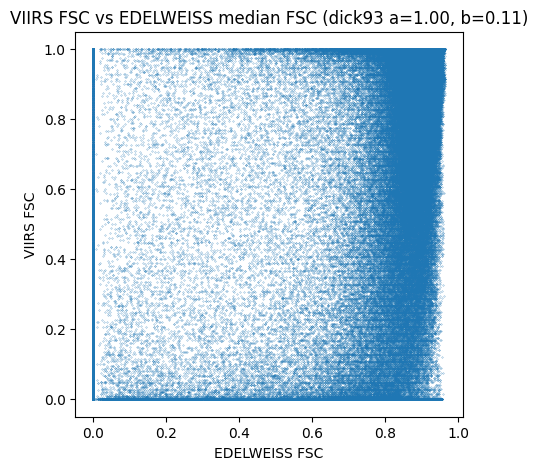

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5))
sd = edel.sel(x=viirs["x"], y=viirs["y"], method="nearest", time=viirs.coords["time"]).median(dim="member")
am, bm = 1.0, 0.11
ax.scatter(dickinson(sd, am, bm), viirs, s=0.04)
# ax.plot(np.arange(0, 2, 0.01), dickinson(sd=np.arange(0, 2, 0.01), a=am, b=bm), "r", linewidth=2)
ax.set_title(f"VIIRS FSC vs EDELWEISS median FSC (dick93 a={am:.2f}, b={bm:.2f})")
ax.set_ylabel("VIIRS FSC")
ax.set_xlabel("EDELWEISS FSC")
# ds = xr.Dataset({'fsc': viirs, 'sd': sd})
# ds.plot.scatter(x='sd',y='fsc',hue='time',s=10, ax=ax)

Text(0.5, 0, 'EDELWEISS FSC')

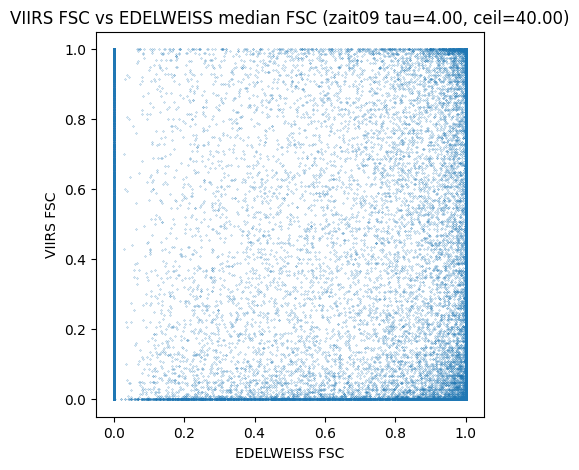

In [27]:
fig, ax = plt.subplots(figsize=(5, 5))
sd = edel.sel(x=viirs["x"], y=viirs["y"], method="nearest", time=viirs.coords["time"]).median(dim="member")
tau, ceil = 4, 40
ax.scatter(zaitchik(sd_to_swe(sd), tau, ceil), viirs, s=0.04)
# ax.plot(np.arange(0, 2, 0.01), dickinson(sd=np.arange(0, 2, 0.01), a=am, b=bm), "r", linewidth=2)
ax.set_title(f"VIIRS FSC vs EDELWEISS median FSC (zait09 tau={tau:.2f}, ceil={ceil:.2f})")
ax.set_ylabel("VIIRS FSC")
ax.set_xlabel("EDELWEISS FSC")
# ds = xr.Dataset({'fsc': viirs, 'sd': sd})
# ds.plot.scatter(x='sd',y='fsc',hue='time',s=10, ax=ax)

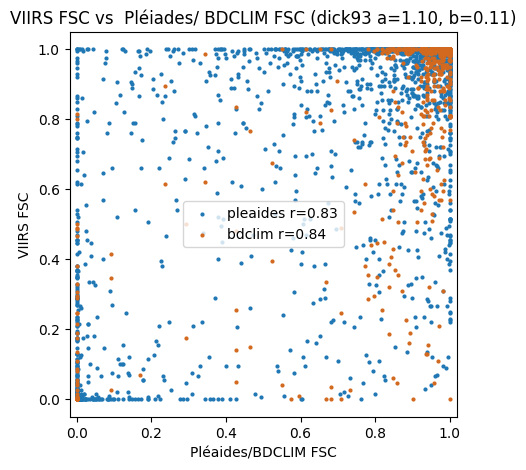

In [7]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr


def dickinson(sd: np.ndarray, a: float, b: float):
    return np.minimum(1, (a * sd) / (sd + b))


am, bm = 1.1, 0.11

fig, ax = plt.subplots(figsize=(5, 5))

sd_pleaides = pleiades.sel(x=viirs["x"], y=viirs["y"], method="nearest")
fsc_pleaides = dickinson(sd_pleaides, am, bm)
fsc_pleaides = fsc_pleaides.where(fsc_pleaides >= 0)
viirs_pleaides = viirs.sel(time=pleiades.coords["time"], method="nearest")

viirs_valid = ~np.isnan(viirs_pleaides.assign_coords({"time": fsc_pleaides.time}))
pleiades_valid = ~np.isnan(fsc_pleaides.sel(band=1))
union = viirs_valid * pleiades_valid
viirs_corr = viirs_pleaides.assign_coords({"time": fsc_pleaides.time}).where(union).values.flatten()
pleaides_corr = fsc_pleaides.where(union).values.flatten()
viirs_corr = viirs_corr[~np.isnan(viirs_corr)]
pleaides_corr = pleaides_corr[~np.isnan(pleaides_corr)]
r_v_p = pearsonr(viirs_corr, pleaides_corr).correlation
ax.scatter(fsc_pleaides, viirs_pleaides, s=4, label=f"pleaides r={r_v_p:.2f}")

sd_bdclim = bdclim.sel(time=viirs.coords["time"], method="nearest")
fsc_bdclim = dickinson(sd_bdclim, am, bm)
viirs_station = viirs.sel(x=bdclim.coords["x"], y=bdclim.coords["y"], method="nearest")

viirs_s_valid = ~np.isnan(viirs_station)
bdclim_valid = ~np.isnan(fsc_bdclim.assign_coords({"time": viirs_station.time}))
union = viirs_s_valid * bdclim_valid
viirs_s_corr = viirs_station.where(union).values.flatten()
bdclim_corr = fsc_bdclim.assign_coords({"time": viirs_station.time}).where(union).values.flatten()
viirs_s_corr = viirs_s_corr[~np.isnan(viirs_s_corr)]
bdclim_corr = bdclim_corr[~np.isnan(bdclim_corr)]
r_v_b = pearsonr(viirs_s_corr, bdclim_corr).correlation

ax.scatter(bdclim_corr, viirs_s_corr, color="chocolate", s=4, label=f"bdclim r={r_v_b:.2f}")
ax.set_title(f"VIIRS FSC vs  Pléiades/ BDCLIM FSC (dick93 a={am:.2f}, b={bm:.2f})")
ax.set_ylabel("VIIRS FSC")
ax.set_xlabel("Pléaides/BDCLIM FSC")
ax.set_xlim(-0.02, 1.02)
ax.legend()


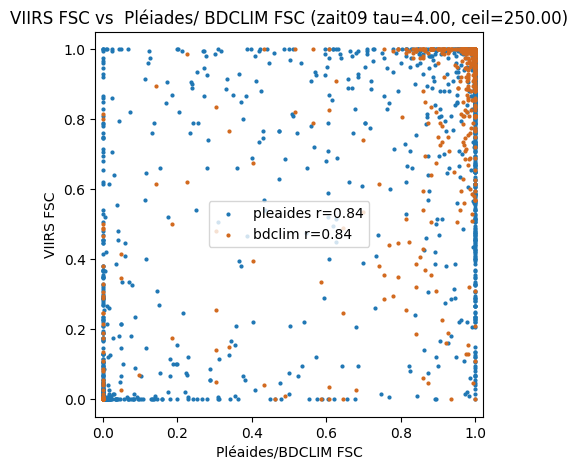

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from edelassim.observation_operators import zaitchik
import numpy as np

tau, ceil = 4, 250

fig, ax = plt.subplots(figsize=(5, 5))

sd_pleaides = pleiades.sel(x=viirs["x"], y=viirs["y"], method="nearest")
fsc_pleaides = zaitchik(sd_pleaides * 1000, tau_scf=tau, swe_full_snow_cover=ceil)
fsc_pleaides = fsc_pleaides.where(fsc_pleaides >= 0)
viirs_pleaides = viirs.sel(time=pleiades.coords["time"], method="nearest")

viirs_valid = ~np.isnan(viirs_pleaides.assign_coords({"time": fsc_pleaides.time}))
pleiades_valid = ~np.isnan(fsc_pleaides.sel(band=1))
union = viirs_valid * pleiades_valid
viirs_corr = viirs_pleaides.assign_coords({"time": fsc_pleaides.time}).where(union).values.flatten()
pleaides_corr = fsc_pleaides.where(union).values.flatten()
viirs_corr = viirs_corr[~np.isnan(viirs_corr)]
pleaides_corr = pleaides_corr[~np.isnan(pleaides_corr)]
r_v_p = pearsonr(viirs_corr, pleaides_corr).correlation
ax.scatter(fsc_pleaides, viirs_pleaides, s=4, label=f"pleaides r={r_v_p:.2f}")

sd_bdclim = bdclim.sel(time=viirs.coords["time"], method="nearest")
fsc_bdclim = zaitchik(sd_to_swe(sd_bdclim), tau_scf=tau, swe_full_snow_cover=ceil)
viirs_station = viirs.sel(x=bdclim.coords["x"], y=bdclim.coords["y"], method="nearest")

viirs_s_valid = ~np.isnan(viirs_station)
bdclim_valid = ~np.isnan(fsc_bdclim.assign_coords({"time": viirs_station.time}))
union = viirs_s_valid * bdclim_valid
viirs_s_corr = viirs_station.where(union).values.flatten()
bdclim_corr = fsc_bdclim.assign_coords({"time": viirs_station.time}).where(union).values.flatten()
viirs_s_corr = viirs_s_corr[~np.isnan(viirs_s_corr)]
bdclim_corr = bdclim_corr[~np.isnan(bdclim_corr)]
r_v_b = pearsonr(viirs_s_corr, bdclim_corr).correlation

ax.scatter(bdclim_corr, viirs_s_corr, color="chocolate", s=4, label=f"bdclim r={r_v_b:.2f}")
ax.set_title(f"VIIRS FSC vs  Pléiades/ BDCLIM FSC (zait09 tau={tau:.2f}, ceil={ceil:.2f})")
ax.set_ylabel("VIIRS FSC")
ax.set_xlabel("Pléaides/BDCLIM FSC")
ax.set_xlim(-0.02, 1.02)
ax.legend()


{'whiskers': [<matplotlib.lines.Line2D at 0x700975c242e0>,
 'caps': [<matplotlib.lines.Line2D at 0x700975c248e0>,
 'boxes': [<matplotlib.lines.Line2D at 0x700975bf7f40>],
 'medians': [<matplotlib.lines.Line2D at 0x700975c24ee0>],
 'fliers': [],
 'means': []}

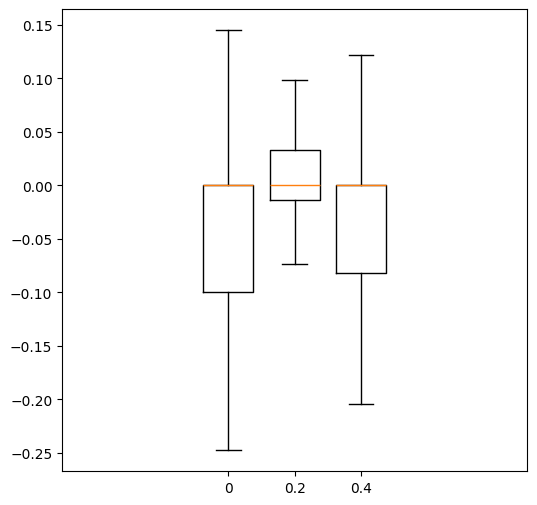

In [34]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.boxplot(viirs_corr - pleaides_corr, positions=[0], showfliers=False)
ax.boxplot(viirs_s_corr - bdclim_corr, positions=[0.2], showfliers=False)
edel_fsc = dickinson(sd, am, bm)
residual_viirs_edel = (viirs - edel_fsc).values.ravel()
residual_viirs_edel = residual_viirs_edel[~np.isnan(residual_viirs_edel)]
# residual_viirs_edel
ax.boxplot(residual_viirs_edel, positions=[0.4], showfliers=False)

In [ ]:
from mountain_data_binner.mountain_binner import MountainBinner, MountainBinnerConfig

mb = MountainBinner.from_dem_and_forest_mask_filepath(
    dem_filepath="./dem_grandesrousses.nc",
    forest_mask_filepath="/home/imperatoren/work/edelweiss_assimilation/data/auxiliary/forest_mask/forest_mask_corine_grandesrousses_max.nc",
    distributed_data_filepath="viirs_edel_gr.nc",
    output_folder="./data/auxiliary",
)

INFO:logger:Opening distributed dataset in target geometry
INFO:logger:Opening DEM data
INFO:logger:Resampling DEM to output grid
INFO:logger:Exporting to ./output_folder/dem.tif
INFO:logger:Generating slope map
INFO:logger:Exported to ./output_folder/slope.tif
INFO:logger:Exported to ./output_folder/aspect.tif
INFO:logger:Opening distributed dataset un target geometry
INFO:logger:Opening forest mask data


0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.


In [ ]:
import xarray as xr
import numpy as np


def calc_rmsd(ds: xr.Dataset):
    return np.sqrt((ds.viirs.values - ds.edel.values) ** 1)


mb.transform(
    distributed_data=xr.open_dataset("viirs_edel_gr.nc"),
    bin_dict=MountainBinner.create_default_bin_dict(altitude_step=3600),
    function=calc_rmsd,
)

MergeError: unable to determine if these variables should be coordinates or not in the merged result: {'spatial_ref'}